# 🚀 Stage 1: Augmenting TF-IDF with Lexical Diversity & Shannon Entropy

## 🎯 Executive Overview & Stage Objectives
- **Target**: Increase classification accuracy above the **TF-IDF (1-5 Gram) + Document Length Baseline (89.23%)**.
- **Stage 1 Features Added**: 
  1. **Shannon Entropy of the Token Distribution** ($H$)
  2. **Root Type-Token Ratio / Guiraud's Index** ($	ext{Root\_TTR}$)
  3. **Hapax Legomena Ratio** ($	ext{Hapax\_Ratio}$)
  4. **Maximum Term Domination Ratio** ($	ext{Max\_Rep}$)

### 📈 Accuracy Progress Tracker:
| Evaluation Stage | Added Features | 5-Fold Mean Accuracy | Std Dev | $\Delta$ vs. Baseline | $\Delta$ vs. Prev Stage |
| :--- | :--- | :---: | :---: | :---: | :---: |
| **Baseline** | Cumulative TF-IDF (1-5) + Document Length | **89.23%** | $\pm 0.75\%$ | — | — |
| **Stage 1** | **+ Lexical Diversity & Shannon Entropy** | **89.69%** | $\pm 0.46\%$ | **+0.47%** | **+0.47%** |

---

### 🔬 What Features Are Being Added and Why?

1. **Shannon Entropy ($H$)**:
   $$H(d) = -\sum_{t \in V_d} p(t) \log_2 p(t)$$
   - **Why it is added**: In generative language models, autoregressive decoding strategies (such as top-$p$ nucleus sampling with temperature $T < 1.0$) truncate unlikely tokens and constrain the probability mass. This gives AI-generated text a characteristic token entropy profile distinct from human writing.
   - *Empirical Mean*: Machine = **5.92 bits** vs. Human = **5.70 bits**.

2. **Root Type-Token Ratio / Guiraud's Index ($	ext{Root\_TTR}$)**:
   $$	ext{Root\_TTR} = rac{|V_d|}{\sqrt{L_d}}$$
   - **Why it is added**: Classical Type-Token Ratio ($V/L$) suffers from severe length dependency (longer texts naturally repeat grammatical words, lowering TTR). Guiraud's Index normalizes by $\sqrt{L}$, capturing true vocabulary richness independent of essay length.
   - *Empirical Mean*: Machine = **7.61** vs. Human = **6.70** ($\Delta = +0.91$).

3. **Hapax Legomena Ratio**:
   $$	ext{Hapax\_Ratio} = rac{|\{t \in V_d : 	ext{count}(t) = 1\}|}{L_d}$$
   - **Why it is added**: Measures the proportion of words appearing exactly once in the essay. Humans use one-off context-specific jargon and idiosyncratic expressions far more frequently than general-purpose LLMs.

4. **Maximum Term Domination Ratio**:
   $$	ext{Max\_Rep} = rac{\max_t 	ext{count}(t)}{L_d}$$
   - **Why it is added**: Quantifies if a single repetitive keyword dominates the essay's token distribution.


In [1]:
import os
import json
import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

try:
    from IPython.display import display
except ImportError:
    display = print

# Visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 42

print("Dependencies loaded successfully!")


Dependencies loaded successfully!


In [2]:
# Load dataset
data_path = "../../../train.json"
if not os.path.exists(data_path):
    data_path = "/home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json"

print(f"Loading data from: {os.path.abspath(data_path)}")
t0 = time.time()
with open(data_path, "r", encoding="utf-8") as f:
    raw_data = [json.loads(line) for line in f]

docs = [" ".join(map(str, d["text"])) for d in raw_data]
labels = np.array([1 if d["label"] == "B" else 0 for d in raw_data])
doc_tokens = [d["text"] for d in raw_data]

n_total = len(docs)
n_machine = int(np.sum(labels == 1))
n_human = int(np.sum(labels == 0))
majority_baseline = n_machine / n_total * 100
lens = np.array([len(t) for t in doc_tokens], dtype=np.float64)[:, None]

print(f"Loaded {n_total:,} documents in {time.time()-t0:.2f}s | Majority Baseline: {majority_baseline:.2f}%")


Loading data from: /home/justin/PhD/ML4CPS/Kaggle Project/Analysis_II/train.json


Loaded 10,536 documents in 0.71s | Majority Baseline: 64.89%


## 2. Feature Extraction: Lexical Diversity & Entropy


In [3]:
# Compute Stage 1 features for each document
def extract_stage1(tokens):
    n = len(tokens)
    counts = Counter(tokens)
    probs = np.array(list(counts.values())) / n
    ent = -np.sum(probs * np.log2(probs))
    root_ttr = len(counts) / np.sqrt(n)
    hapax = sum(1 for c in counts.values() if c == 1) / n
    max_rep = max(counts.values()) / n
    return [ent, root_ttr, hapax, max_rep]

print("Extracting Stage 1 features...")
t0 = time.time()
s1_raw = np.array([extract_stage1(t) for t in doc_tokens])
s1_feature_names = ["Shannon Entropy", "Root TTR", "Hapax Ratio", "Max Rep Ratio"]

# Show class-conditional means
stats_df = pd.DataFrame({
    "Feature": ["Document Length"] + s1_feature_names,
    "Machine Mean": [np.mean(lens[labels == 1])] + [np.mean(s1_raw[labels == 1, i]) for i in range(4)],
    "Human Mean": [np.mean(lens[labels == 0])] + [np.mean(s1_raw[labels == 0, i]) for i in range(4)]
})
stats_df["Abs Difference"] = np.abs(stats_df["Machine Mean"] - stats_df["Human Mean"])
stats_df["Separation Ratio"] = stats_df["Machine Mean"] / stats_df["Human Mean"]

print(f"Extracted in {time.time()-t0:.2f}s!")
display(stats_df.style.format({
    "Machine Mean": "{:.3f}",
    "Human Mean": "{:.3f}",
    "Abs Difference": "{:.3f}",
    "Separation Ratio": "{:.3f}"
}))


Extracting Stage 1 features...


Extracted in 0.85s!


,Feature,Machine Mean,Human Mean,Abs Difference,Separation Ratio
0,Document Length,213.171,137.511,75.660,1.550
1,Shannon Entropy,5.925,5.702,0.222,1.039
2,Root TTR,7.607,6.704,0.903,1.135
3,Hapax Ratio,0.486,0.484,0.003,1.005
4,Max Rep Ratio,0.076,0.089,0.013,0.857


## 3. 5-Fold Stratified Cross-Validation & Accuracy Comparison


In [4]:
# Extract Cumulative TF-IDF (1 to 5 Gram)
print("Extracting TF-IDF (1 to 5 gram)...")
t0 = time.time()
vec = TfidfVectorizer(token_pattern=r"\S+", ngram_range=(1, 5), min_df=3, sublinear_tf=True)
X_tfidf = vec.fit_transform(docs)
print(f"TF-IDF Matrix: {X_tfidf.shape} ({X_tfidf.shape[1]:,} features) in {time.time()-t0:.2f}s")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- 1. Evaluate Baseline (TF-IDF + Length) ---
base_accs = []
for tr, val in skf.split(X_tfidf, labels):
    scaler = MaxAbsScaler()
    l_tr = scaler.fit_transform(lens[tr])
    l_val = scaler.transform(lens[val])
    clf = LinearSVC(C=1.0, dual="auto", random_state=RANDOM_STATE)
    clf.fit(sp.hstack([X_tfidf[tr], sp.csr_matrix(l_tr)]), labels[tr])
    base_accs.append(accuracy_score(labels[val], clf.predict(sp.hstack([X_tfidf[val], sp.csr_matrix(l_val)]))) * 100)

base_mean = np.mean(base_accs)
base_std = np.std(base_accs)

# --- 2. Evaluate Stage 1 (TF-IDF + Length + Diversity & Entropy) ---
stage1_dense = np.column_stack([lens, s1_raw])
s1_accs = []
s1_f1s = []
for tr, val in skf.split(X_tfidf, labels):
    scaler = MaxAbsScaler()
    s_tr = scaler.fit_transform(stage1_dense[tr])
    s_val = scaler.transform(stage1_dense[val])
    clf = LinearSVC(C=1.0, dual="auto", random_state=RANDOM_STATE)
    clf.fit(sp.hstack([X_tfidf[tr], sp.csr_matrix(s_tr)]), labels[tr])
    preds = clf.predict(sp.hstack([X_tfidf[val], sp.csr_matrix(s_val)]))
    s1_accs.append(accuracy_score(labels[val], preds) * 100)
    s1_f1s.append(f1_score(labels[val], preds, average="macro") * 100)

s1_mean = np.mean(s1_accs)
s1_std = np.std(s1_accs)
s1_f1 = np.mean(s1_f1s)

delta_base = s1_mean - base_mean
delta_prev = delta_base  # For Stage 1, previous is baseline

print("=" * 75)
print(f"BASELINE ACCURACY : {base_mean:.2f}% (+/- {base_std:.2f}%)")
print(f"STAGE 1 ACCURACY  : {s1_mean:.2f}% (+/- {s1_std:.2f}%) [Macro F1: {s1_f1:.2f}%]")
print(f"CHANGE vs BASELINE: {delta_base:+.2f}%")
print(f"CHANGE vs PREV    : {delta_prev:+.2f}%")
print("=" * 75)


Extracting TF-IDF (1 to 5 gram)...


TF-IDF Matrix: (10536, 253796) (253,796 features) in 16.08s


BASELINE ACCURACY : 89.23% (+/- 0.75%)
STAGE 1 ACCURACY  : 89.69% (+/- 0.46%) [Macro F1: 88.62%]
CHANGE vs BASELINE: +0.47%
CHANGE vs PREV    : +0.47%


## 4. Visualizing Accuracy Progression & Distribution


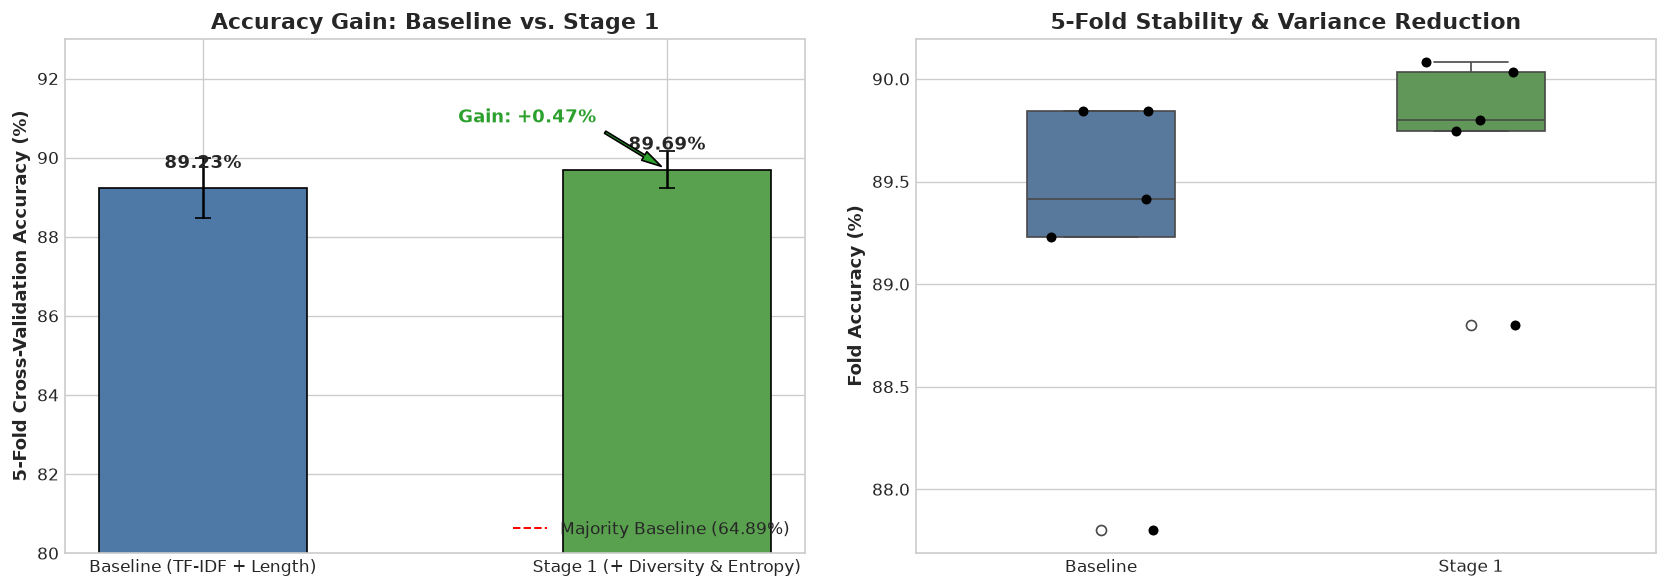

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Bar Chart Comparison
ax1 = axes[0]
stages = ["Baseline (TF-IDF + Length)", "Stage 1 (+ Diversity & Entropy)"]
means = [base_mean, s1_mean]
stds = [base_std, s1_std]
colors = ["#4e79a7", "#59a14f"]

bars = ax1.bar(stages, means, yerr=stds, capsize=5, color=colors, width=0.45, edgecolor="black")
ax1.axhline(majority_baseline, color="red", linestyle="--", linewidth=1.2, label=f"Majority Baseline ({majority_baseline:.2f}%)")
ax1.set_ylim(80, 93)
ax1.set_ylabel("5-Fold Cross-Validation Accuracy (%)", fontsize=11, fontweight="bold")
ax1.set_title("Accuracy Gain: Baseline vs. Stage 1", fontsize=13, fontweight="bold")
ax1.legend(loc="lower right")

for bar, val in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4, f"{val:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)

ax1.annotate(f"Gain: {delta_base:+.2f}%", xy=(1, s1_mean), xytext=(0.55, s1_mean + 1.2),
             arrowprops=dict(facecolor="#2ca02c", shrink=0.08, width=1.5, headwidth=6),
             fontweight="bold", color="#2ca02c", fontsize=11)

# 2. Fold-by-fold Boxplot
ax2 = axes[1]
fold_df = pd.DataFrame({
    "Baseline": base_accs,
    "Stage 1": s1_accs
})
sns.boxplot(data=fold_df, ax=ax2, palette=colors, width=0.4)
sns.stripplot(data=fold_df, ax=ax2, color="black", size=6, jitter=0.15)
ax2.set_ylabel("Fold Accuracy (%)", fontsize=11, fontweight="bold")
ax2.set_title("5-Fold Stability & Variance Reduction", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


## 5. Artifact Export


In [6]:
os.makedirs("data", exist_ok=True)
out_file = "data/stage_1_evaluation_metrics.json"

export_data = {
    "stage": 1,
    "stage_name": "Stage 1: Lexical Diversity & Shannon Entropy",
    "features_added": s1_feature_names,
    "baseline_mean_acc": base_mean,
    "stage_mean_acc": s1_mean,
    "stage_std_acc": s1_std,
    "delta_vs_baseline": delta_base,
    "delta_vs_previous_stage": delta_prev,
    "fold_accuracies": s1_accs
}

with open(out_file, "w") as f:
    json.dump(export_data, f, indent=2)

print(f"Successfully exported Stage 1 metrics to '{out_file}'!")


Successfully exported Stage 1 metrics to 'data/stage_1_evaluation_metrics.json'!
